In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("PROCESSED_DIR:", PROCESSED_DIR)

PROCESSED_DIR: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed


In [3]:
EMOTIBIT_IDS = [f"EmotiBit_{i}" for i in range(1, 8)]
SEGMENTS = ["pre_meditation", "main_meditation", "recovery"]
CHANNELS = ["PPG_1", "PPG_2", "PPG_3"]

In [4]:
def load_segment_csv(emotibit_id, segment):
    path = PROCESSED_DIR / f"{emotibit_id}_{segment}.csv"
    if not path.exists():
        return None, path
    return pd.read_csv(path), path


def robust_zscore(x):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    if mad == 0 or np.isnan(mad):
        return np.full_like(x, np.nan, dtype=float)
    return 0.6745 * (x - med) / mad


def summarize_channel(x):
    x = np.asarray(x, dtype=float)

    summary = {
        "n": len(x),
        "n_nan": int(np.isnan(x).sum()),
        "mean": np.nanmean(x),
        "std": np.nanstd(x),
        "min": np.nanmin(x),
        "max": np.nanmax(x),
        "range": np.nanmax(x) - np.nanmin(x),
    }

    dx = np.diff(x)
    summary["diff_std"] = np.nanstd(dx) if len(dx) > 0 else np.nan

    z = robust_zscore(x)
    if np.all(np.isnan(z)):
        summary["outlier_frac_abs_z_gt_5"] = np.nan
    else:
        summary["outlier_frac_abs_z_gt_5"] = np.nanmean(np.abs(z) > 5)

    return summary


def normalize_for_plot(x):
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    if sd == 0 or np.isnan(sd):
        return x - mu
    return (x - mu) / sd

In [5]:
rows = []

for emotibit_id in EMOTIBIT_IDS:
    for segment in SEGMENTS:
        df, path = load_segment_csv(emotibit_id, segment)

        if df is None:
            print("Missing file:", path)
            continue

        for ch in CHANNELS:
            s = summarize_channel(df[ch].values)

            rows.append({
                "emotibit_id": emotibit_id,
                "segment": segment,
                "channel": ch,
                **s
            })

channel_quality_summary = pd.DataFrame(rows)
display(channel_quality_summary.head(20))

,emotibit_id,segment,channel,n,n_nan,mean,std,min,max,range,diff_std,outlier_frac_abs_z_gt_5
0,EmotiBit_1,pre_meditation,PPG_1,24288,0,128952.217185,358.820865,128428.0,130031.0,1603.0,25.095682,0.203310
1,EmotiBit_1,pre_meditation,PPG_2,24288,0,76159.517787,135.818953,75817.0,76417.0,600.0,23.539243,0.000000
2,EmotiBit_1,pre_meditation,PPG_3,24288,0,4729.161438,32.391159,4627.0,4839.0,212.0,22.073411,0.000000
3,EmotiBit_1,main_meditation,PPG_1,74968,0,127208.647570,669.902309,125260.0,128736.0,3476.0,25.265772,0.000000
4,EmotiBit_1,main_meditation,PPG_2,74968,0,76381.220974,235.446226,75977.0,77022.0,1045.0,23.673297,0.000000
5,EmotiBit_1,main_meditation,PPG_3,74968,0,4752.664510,30.025865,4557.0,4854.0,297.0,22.342707,0.004562
6,EmotiBit_1,recovery,PPG_1,9430,0,126502.448674,311.895650,124980.0,126946.0,1966.0,25.333333,0.117391
7,EmotiBit_1,recovery,PPG_2,9430,0,76866.845281,226.796595,76158.0,77163.0,1005.0,23.527667,0.102651
8,EmotiBit_1,recovery,PPG_3,9430,0,4763.569247,40.971128,4555.0,4848.0,293.0,22.472486,0.057158
9,EmotiBit_2,pre_meditation,PPG_1,24416,0,106624.821797,146.482052,106315.0,107019.0,704.0,25.280215,0.000000


In [6]:
out_path = TABLES_DIR / "ppg_channel_quality_summary.csv"
channel_quality_summary.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/ppg_channel_quality_summary.csv


Compare channels within each participant during main meditation

In [7]:
main_only = channel_quality_summary[channel_quality_summary["segment"] == "main_meditation"].copy()

display(
    main_only.sort_values(["emotibit_id", "channel"])[
        ["emotibit_id", "channel", "std", "range", "diff_std", "outlier_frac_abs_z_gt_5"]
    ]
)

,emotibit_id,channel,std,range,diff_std,outlier_frac_abs_z_gt_5
3,EmotiBit_1,PPG_1,669.902309,3476.0,25.265772,0.000000
4,EmotiBit_1,PPG_2,235.446226,1045.0,23.673297,0.000000
5,EmotiBit_1,PPG_3,30.025865,297.0,22.342707,0.004562
12,EmotiBit_2,PPG_1,1199.388913,4205.0,26.213059,0.000000
13,EmotiBit_2,PPG_2,402.534733,90382.0,463.698407,0.000013
14,EmotiBit_2,PPG_3,39.355266,250.0,23.034608,0.000000
21,EmotiBit_3,PPG_1,1594.103293,5029.0,26.066077,0.000000
22,EmotiBit_3,PPG_2,1066.884305,153753.0,679.003077,0.000027
23,EmotiBit_3,PPG_3,115.808646,564.0,21.522985,0.000000
30,EmotiBit_4,PPG_1,331.995422,1841.0,28.850684,0.000000


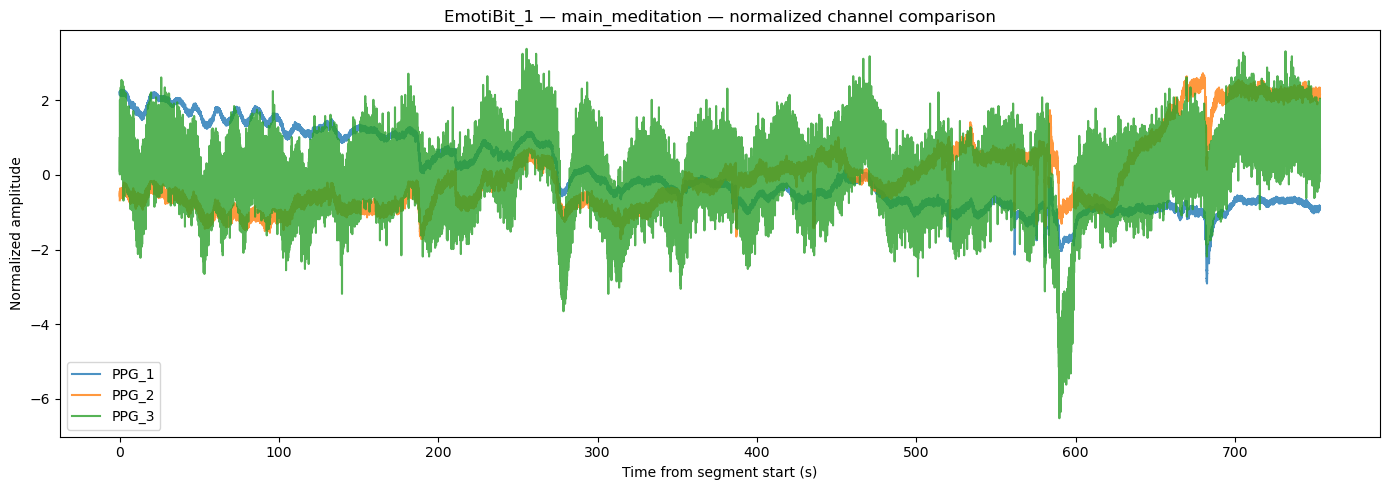

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_1_main_meditation_channel_comparison.png


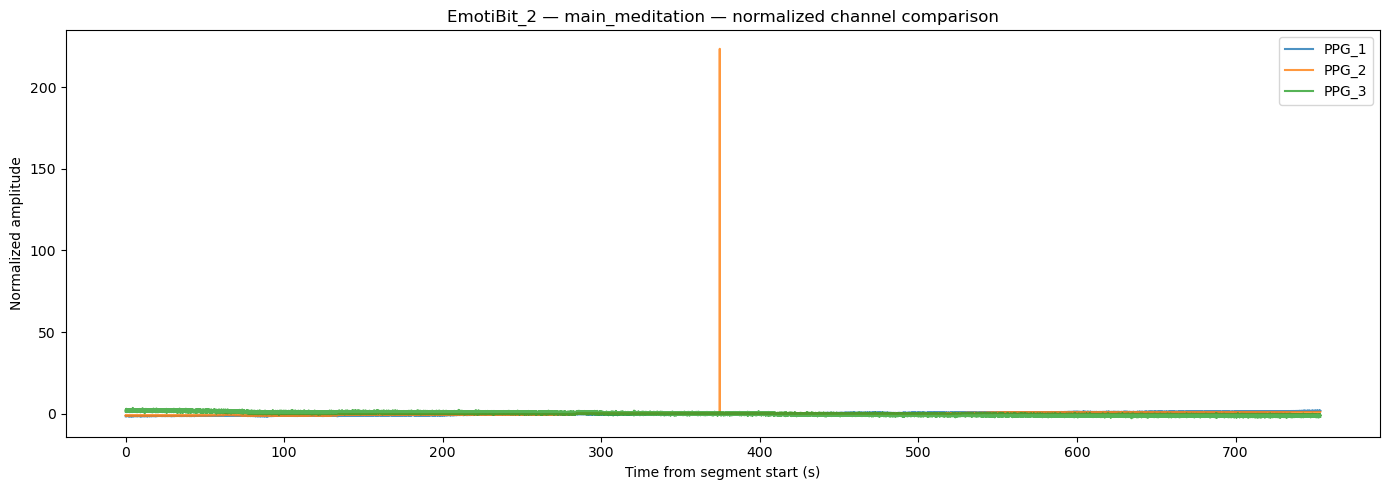

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_2_main_meditation_channel_comparison.png


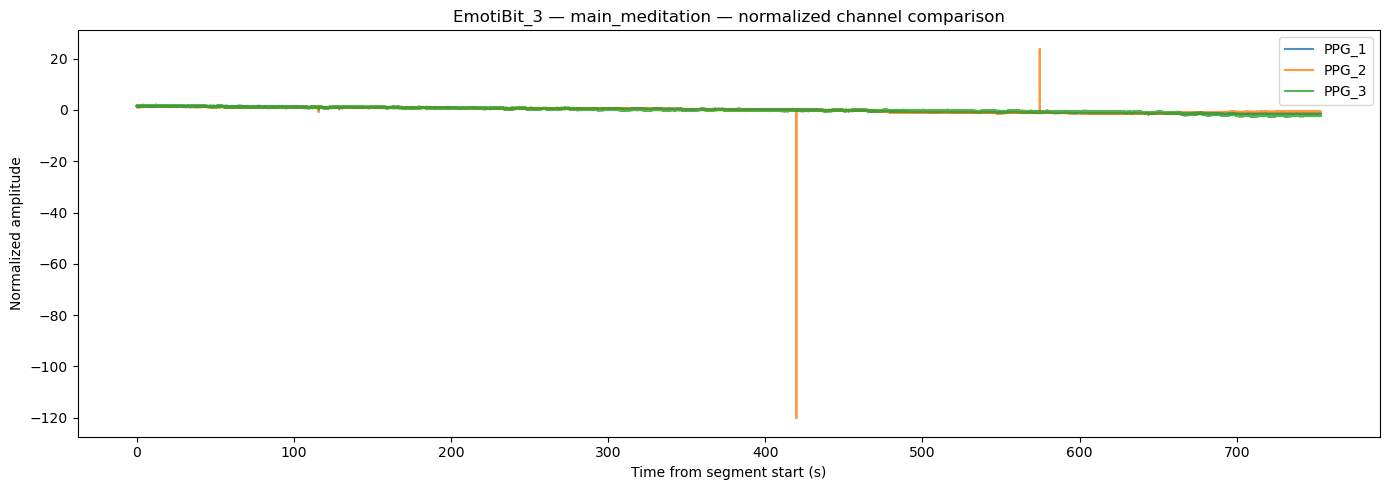

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_3_main_meditation_channel_comparison.png


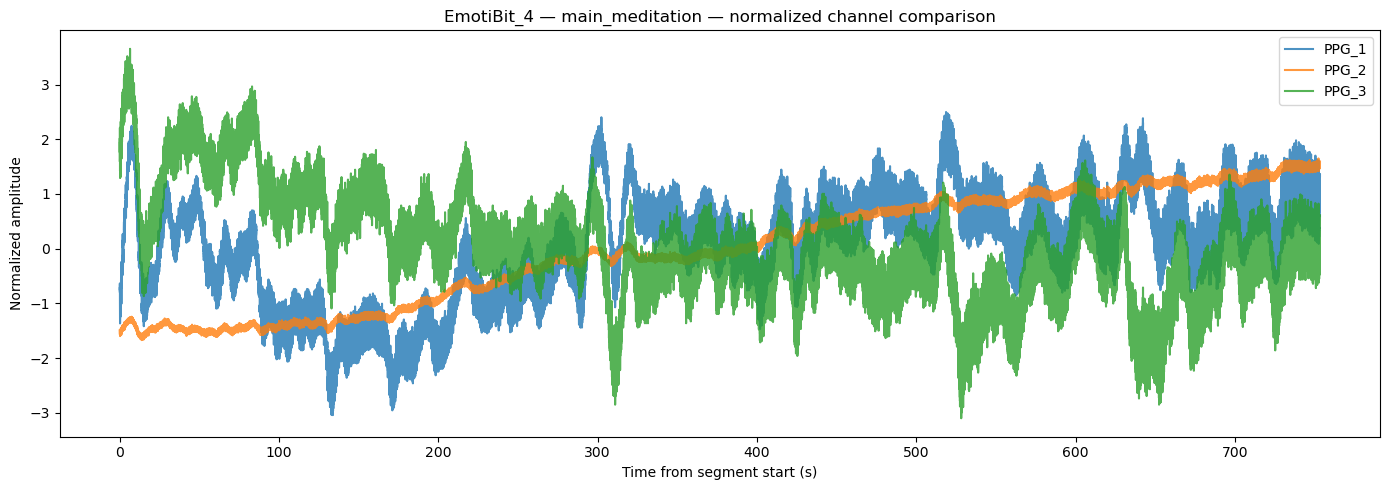

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_4_main_meditation_channel_comparison.png


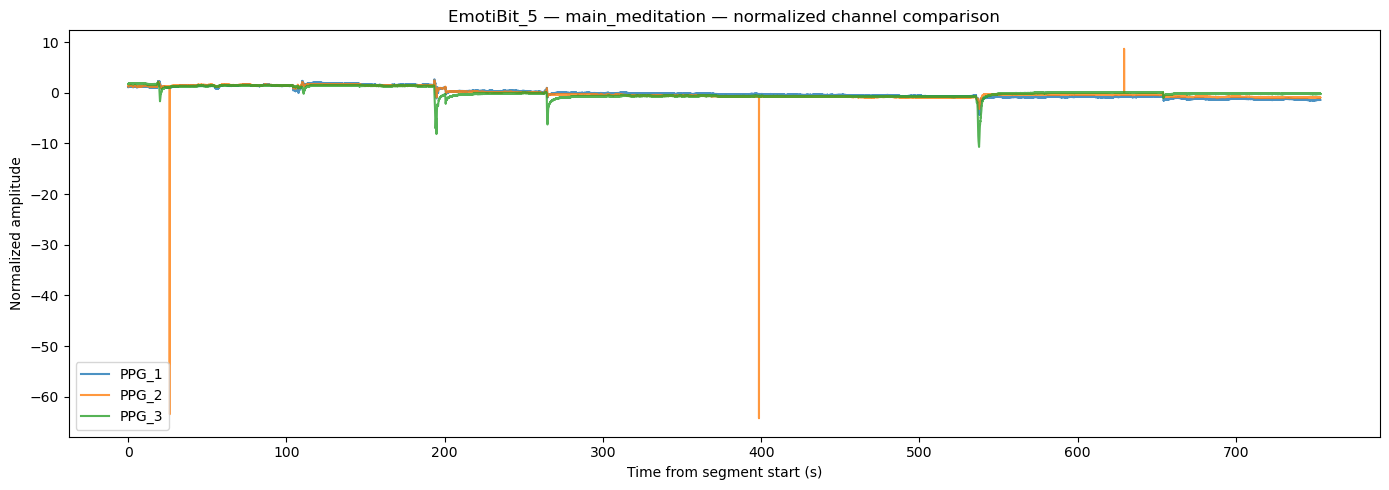

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_5_main_meditation_channel_comparison.png


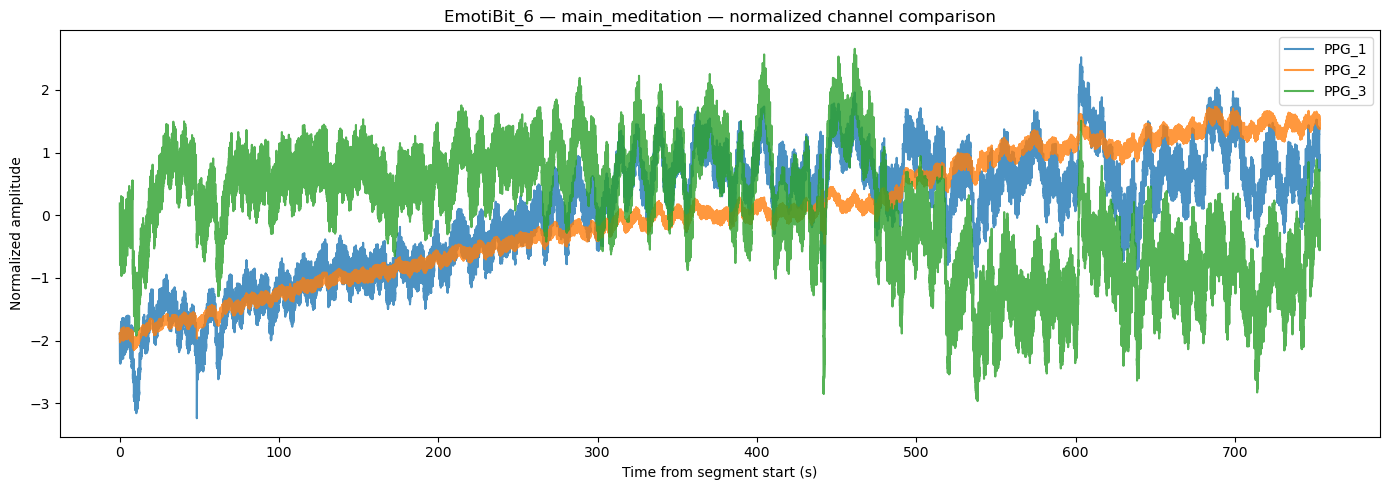

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_6_main_meditation_channel_comparison.png


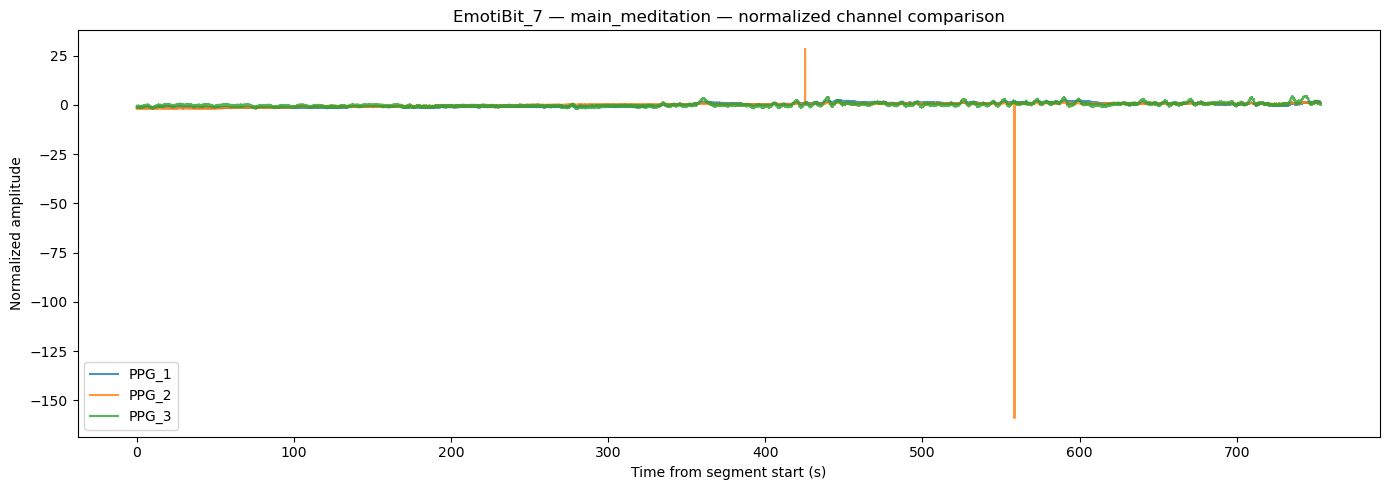

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_7_main_meditation_channel_comparison.png


In [8]:
for emotibit_id in EMOTIBIT_IDS:
    df, path = load_segment_csv(emotibit_id, "main_meditation")
    if df is None:
        continue

    plt.figure(figsize=(14, 5))

    t = df["time_from_segment_start_sec"].values

    for ch in CHANNELS:
        y = normalize_for_plot(df[ch].values)
        plt.plot(t, y, label=ch, alpha=0.8)

    plt.title(f"{emotibit_id} — main_meditation — normalized channel comparison")
    plt.xlabel("Time from segment start (s)")
    plt.ylabel("Normalized amplitude")
    plt.legend()
    plt.tight_layout()

    out_path = FIGURES_DIR / f"{emotibit_id}_main_meditation_channel_comparison.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

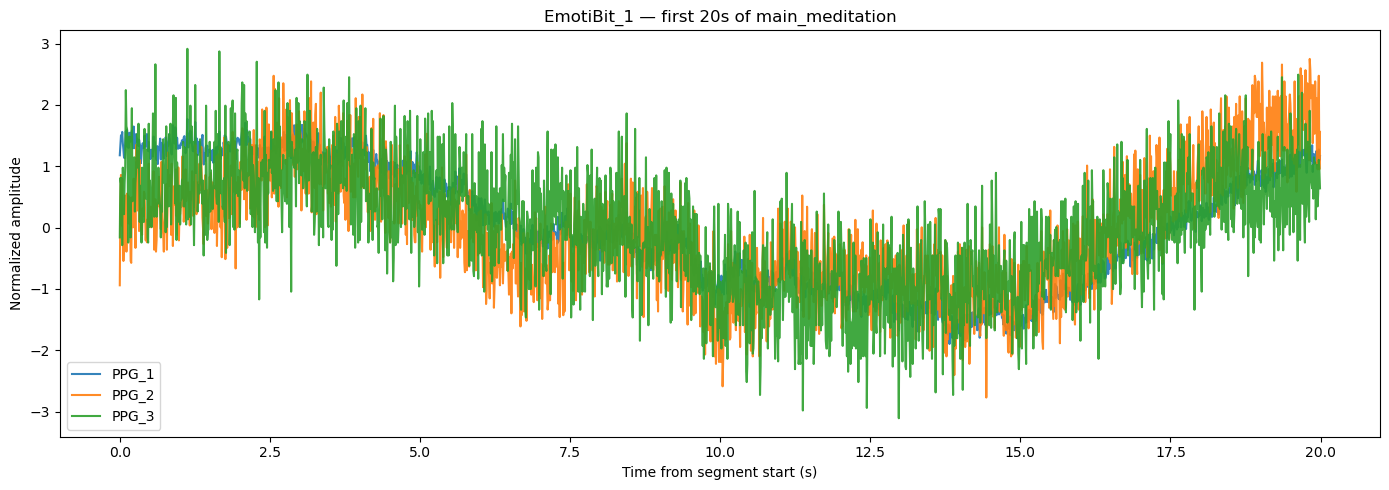

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_1_main_meditation_first20s.png


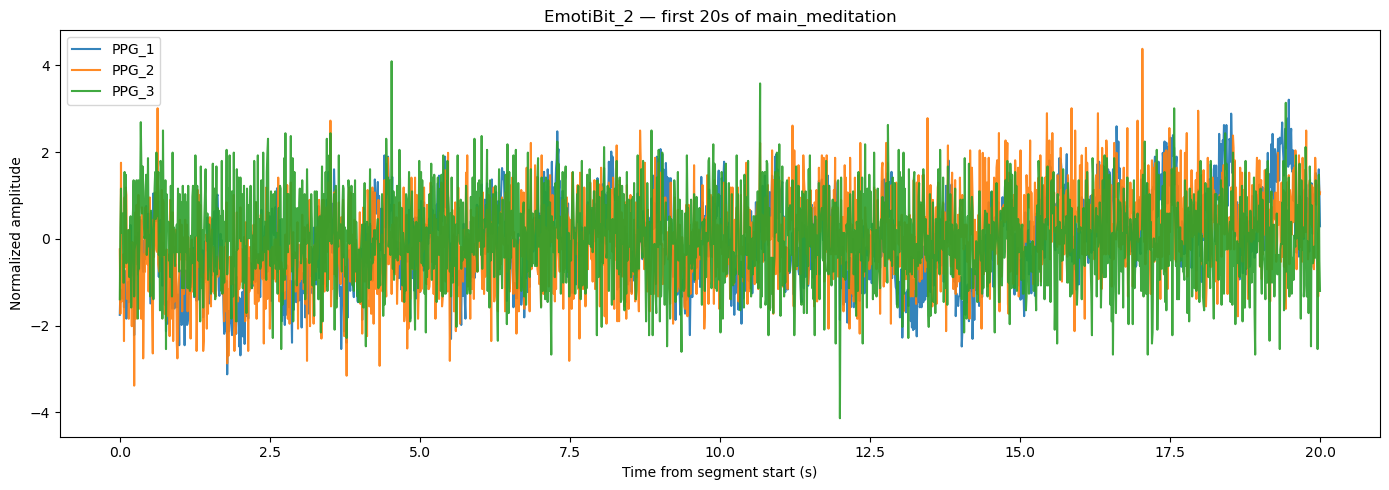

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_2_main_meditation_first20s.png


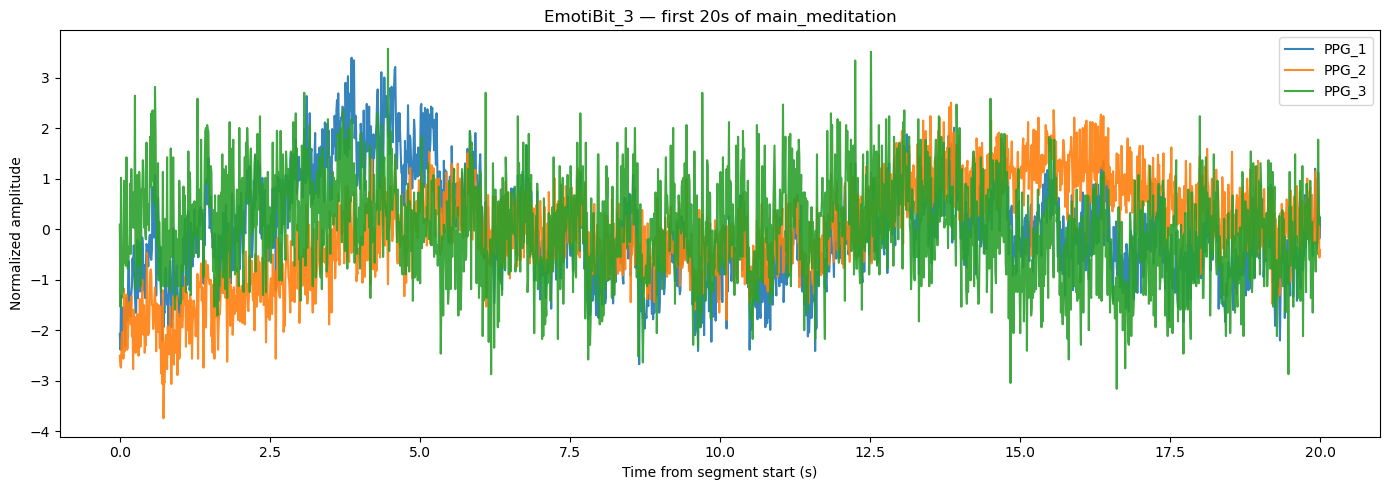

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_3_main_meditation_first20s.png


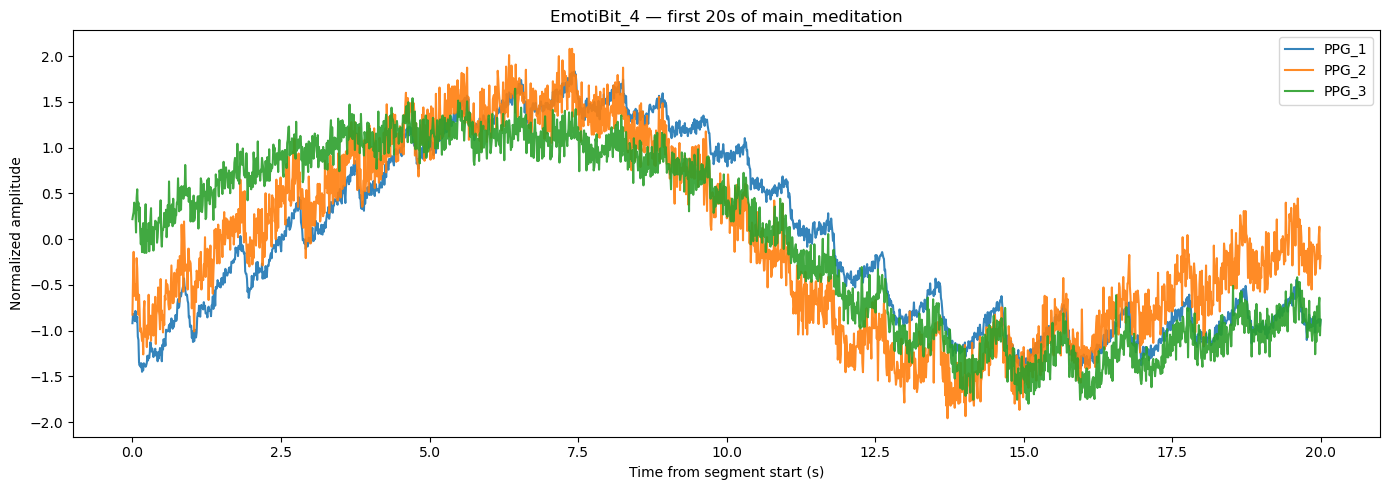

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_4_main_meditation_first20s.png


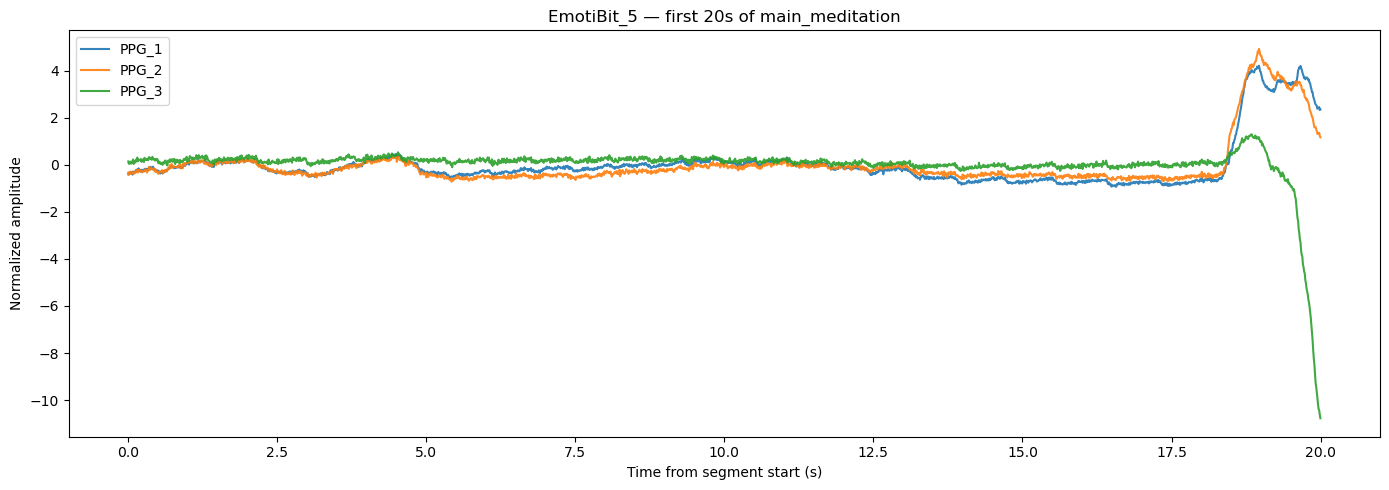

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_5_main_meditation_first20s.png


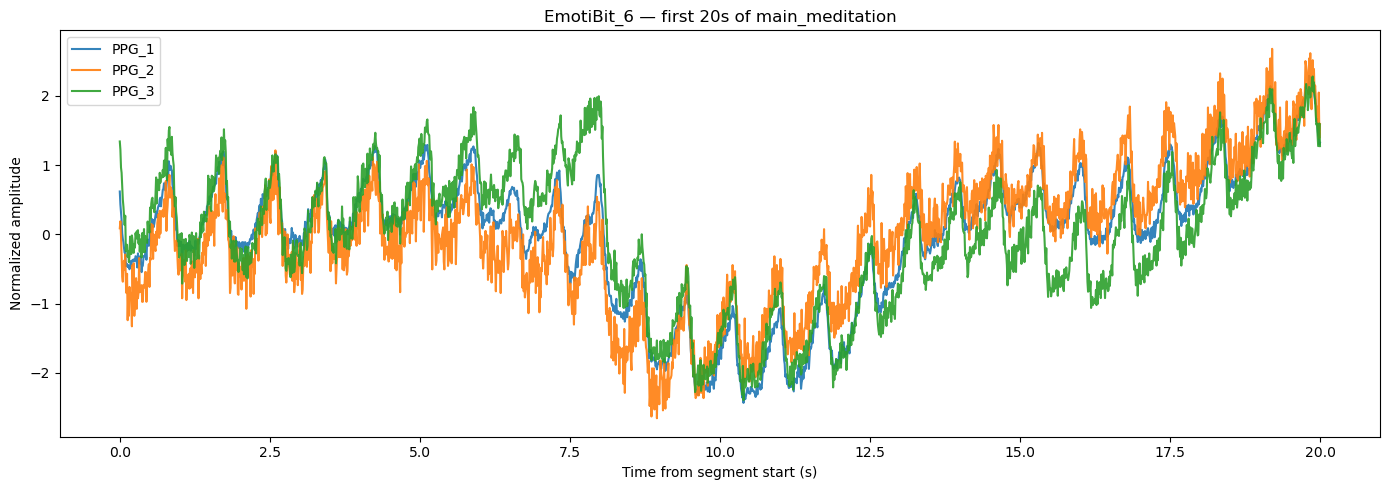

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_6_main_meditation_first20s.png


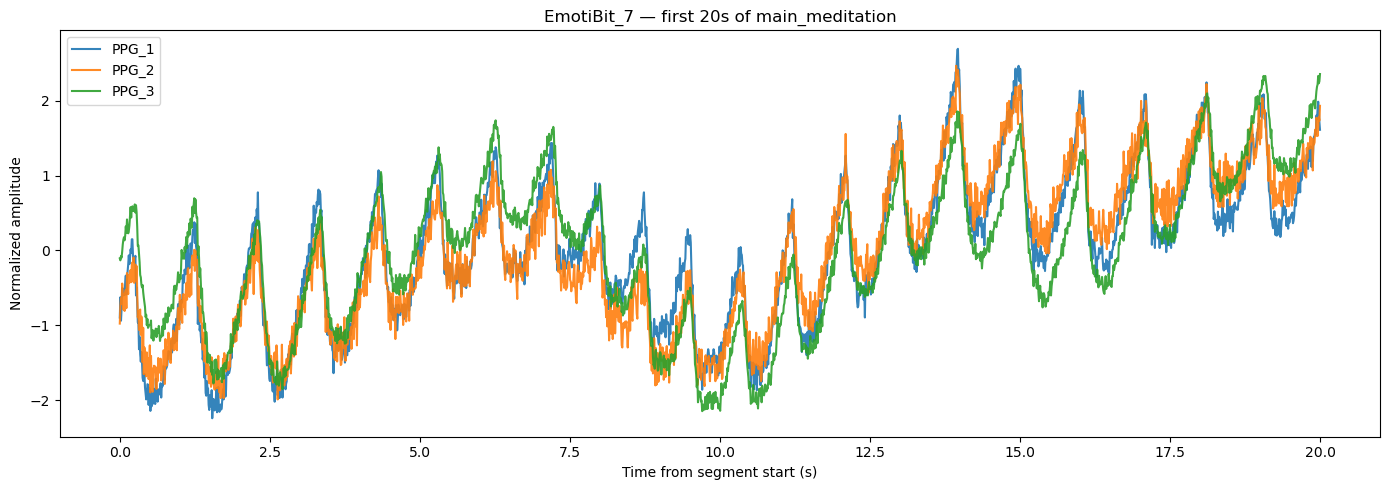

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_7_main_meditation_first20s.png


In [9]:
for emotibit_id in EMOTIBIT_IDS:
    df, path = load_segment_csv(emotibit_id, "main_meditation")
    if df is None:
        continue

    zoom_df = df[df["time_from_segment_start_sec"] <= 20].copy()
    if len(zoom_df) == 0:
        continue

    plt.figure(figsize=(14, 5))

    t = zoom_df["time_from_segment_start_sec"].values

    for ch in CHANNELS:
        y = normalize_for_plot(zoom_df[ch].values)
        plt.plot(t, y, label=ch, alpha=0.9)

    plt.title(f"{emotibit_id} — first 20s of main_meditation")
    plt.xlabel("Time from segment start (s)")
    plt.ylabel("Normalized amplitude")
    plt.legend()
    plt.tight_layout()

    out_path = FIGURES_DIR / f"{emotibit_id}_main_meditation_first20s.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

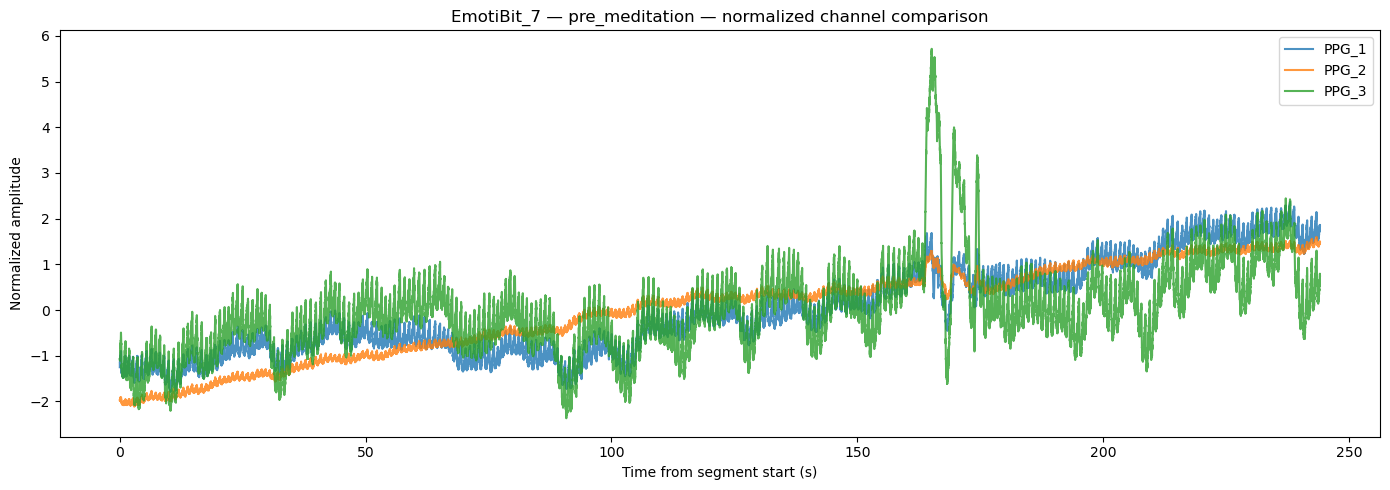

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_7_pre_meditation_channel_comparison.png


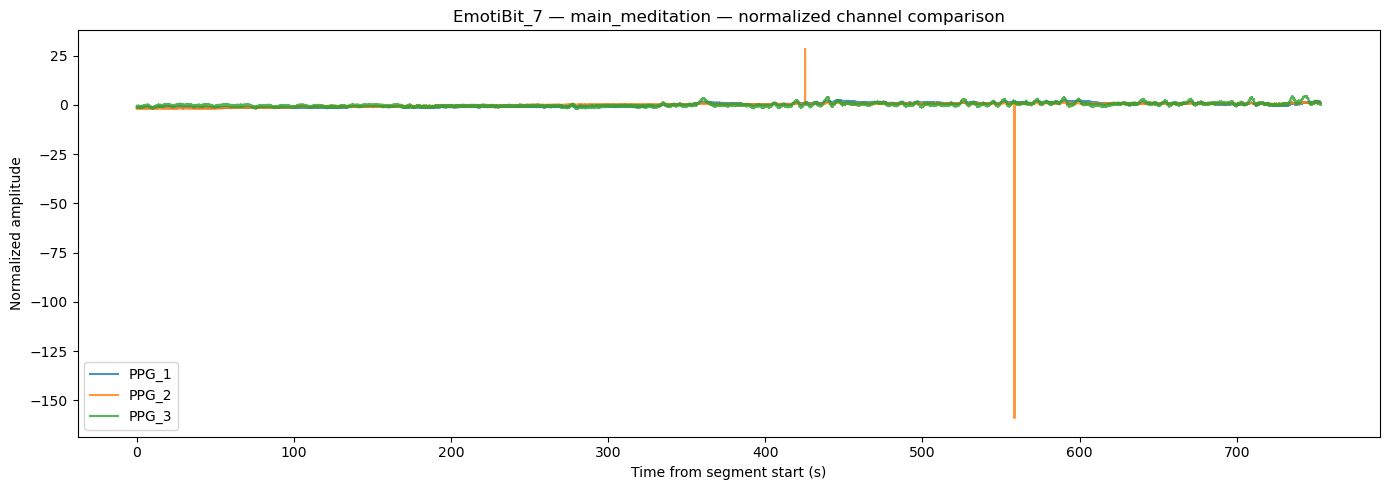

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_7_main_meditation_channel_comparison.png


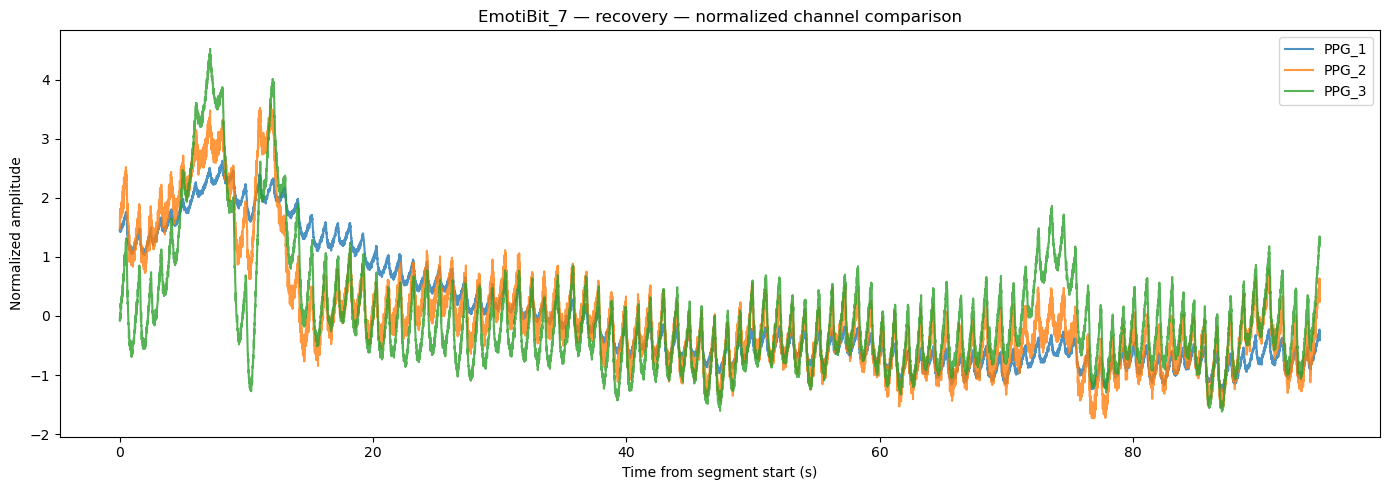

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_7_recovery_channel_comparison.png


In [26]:
SELECTED_EMOTIBIT = "EmotiBit_7"

for segment in SEGMENTS:
    df, path = load_segment_csv(SELECTED_EMOTIBIT, segment)
    if df is None:
        continue

    plt.figure(figsize=(14, 5))
    t = df["time_from_segment_start_sec"].values

    for ch in CHANNELS:
        y = normalize_for_plot(df[ch].values)
        plt.plot(t, y, label=ch, alpha=0.8)

    plt.title(f"{SELECTED_EMOTIBIT} — {segment} — normalized channel comparison")
    plt.xlabel("Time from segment start (s)")
    plt.ylabel("Normalized amplitude")
    plt.legend()
    plt.tight_layout()

    out_path = FIGURES_DIR / f"{SELECTED_EMOTIBIT}_{segment}_channel_comparison.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

In [17]:
tmp = channel_quality_summary.copy()

# Fill NaNs conservatively
tmp["outlier_frac_abs_z_gt_5"] = tmp["outlier_frac_abs_z_gt_5"].fillna(np.inf)
tmp["std_rank"] = tmp.groupby(["emotibit_id", "segment"])["std"].rank(ascending=False, method="min")
tmp["noise_rank"] = tmp.groupby(["emotibit_id", "segment"])["diff_std"].rank(ascending=True, method="min")
tmp["outlier_rank"] = tmp.groupby(["emotibit_id", "segment"])["outlier_frac_abs_z_gt_5"].rank(ascending=True, method="min")

tmp["heuristic_score"] = tmp["std_rank"] + tmp["noise_rank"] + tmp["outlier_rank"]

best_channel_guess = (
    tmp.sort_values(["emotibit_id", "segment", "heuristic_score", "channel"])
       .groupby(["emotibit_id", "segment"], as_index=False)
       .first()
)

display(best_channel_guess[
    ["emotibit_id", "segment", "channel", "heuristic_score", "std", "diff_std", "outlier_frac_abs_z_gt_5"]
])

,emotibit_id,segment,channel,heuristic_score,std,diff_std,outlier_frac_abs_z_gt_5
0,EmotiBit_1,main_meditation,PPG_1,5.0,669.902309,25.265772,0.000000
1,EmotiBit_1,pre_meditation,PPG_2,5.0,135.818953,23.539243,0.000000
2,EmotiBit_1,recovery,PPG_3,5.0,40.971128,22.472486,0.057158
3,EmotiBit_2,main_meditation,PPG_1,4.0,1199.388913,26.213059,0.000000
4,EmotiBit_2,pre_meditation,PPG_1,5.0,146.482052,25.280215,0.000000
5,EmotiBit_2,recovery,PPG_1,5.0,185.453129,26.180212,0.000000
6,EmotiBit_3,main_meditation,PPG_1,4.0,1594.103293,26.066077,0.000000
7,EmotiBit_3,pre_meditation,PPG_3,5.0,25.212797,21.369130,0.000414
8,EmotiBit_3,recovery,PPG_1,5.0,757.386498,28.289646,0.187947
9,EmotiBit_4,main_meditation,PPG_2,4.0,825.733776,23.489360,0.000000


In [18]:
out_path = TABLES_DIR / "ppg_best_channel_guess.csv"
best_channel_guess.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/ppg_best_channel_guess.csv


In [19]:
print("=== CHANNEL INSPECTION SUMMARY ===")
print("This notebook does NOT finalize the channel yet.")
print("It gives us:")
print("1. visual comparison of PPG_1, PPG_2, PPG_3")
print("2. simple quality summary stats")
print("3. a rough heuristic best-channel guess")
print()
print("Next step after inspection:")
print("Choose channel strategy for HR extraction.")

=== CHANNEL INSPECTION SUMMARY ===
This notebook does NOT finalize the channel yet.
It gives us:
1. visual comparison of PPG_1, PPG_2, PPG_3
2. simple quality summary stats
3. a rough heuristic best-channel guess

Next step after inspection:
Choose channel strategy for HR extraction.
